# Study 261 -- Put-Call-Ratio
## For the curious: does the CBOE put/call ratio time market bottoms?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

When traders get scared, they buy puts. The **CBOE total put/call ratio** -- puts
traded divided by calls traded -- is the classic "fear gauge by flow". The
folklore is irresistibly contrarian: when everyone is buying puts (ratio spikes
high), the crowd is *too* fearful, the selling is exhausted, and the market is
near a **bottom** -- so a high put/call ratio is a *buy*.

We test the simplest honest version: read the ratio at month-end, and if it is in
its top quintile of history (extreme fear), hold the S&P 500 for the next month;
otherwise sit in cash. Does buying the fear beat just owning the index?


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from put_call_ratio import data, strategy as st

CACHE_PATH = data.GSPC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    panel = data.build_real_panel(fetch=False)
    sig = st.extreme_signal(panel["pcr"], q=0.80)
    tr = st.timing_returns(panel, q=0.80, one_way_bps=5.0)
    print(f"Real panel loaded: {len(panel)} months  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Active (post-burn-in) months: {len(tr)}")
else:
    panel = sig = tr = None
    print("No real ^GSPC cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 276 months  2003-01-31 -> 2025-12-31
Active (post-burn-in) months: 240


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 276, 'n_active': 240, 'fingerprint': '8edbde520f70', 'pcr_mean': 0.913, 'pcr_std': 0.107, 'reg_slope': -0.0007, 'reg_t': -0.16, 'reg_r2': 0.0002, 'reg_n': 240, 'in_mkt_frac': 0.262, 'strat_ann': 2.18, 'strat_t': 1.02, 'strat_sr': 0.2, 'strat_hit': 0.163, 'strat_dd': -0.371, 'strat_net_ann': 2.02, 'strat_net_t': 0.95, 'bh_ann': 9.63, 'bh_t': 2.81, 'bh_sr': 0.64, 'bh_dd': -0.526, 'n_switches': 64, 'fear_n': 63, 'fear_mean': 0.693, 'fear_t': 1.02, 'calm_n': 177, 'calm_mean': 0.842, 'calm_t': 3.11, 'fear_minus_calm': -0.149, 'welch_t': -0.18, 'welch_p': 0.856, 'perm_p': 0.615, 'rand_mean': 0.815, 'sub1_lab': '2006-2012', 'sub1': -2.0, 'sub1_t': -0.41, 'sub1_n': 84, 'sub1_bh': 3.7, 'sub2_lab': '2013-2019', 'sub2': 3.5, 'sub2_t': 1.91, 'sub2_n': 84, 'sub2_bh': 11.6, 'sub3_lab': '2020-2025', 'sub3': 5.5, 'sub3_t': 1.69, 'sub3_n': 72, 'sub3_bh': 14.3, 'syn_null_t': -0.95, 'syn_live_t': 6.98, 'syn_strong_t': 14.81}


## The put/call ratio and where it spikes

The ratio averages around **0.92** and spikes above ~1.15 in genuine panics:
October 2008 (Lehman), December 2018 (the Powell-pivot selloff), March 2020
(COVID crash). Those spikes are exactly the months the contrarian story says you
should be buying.


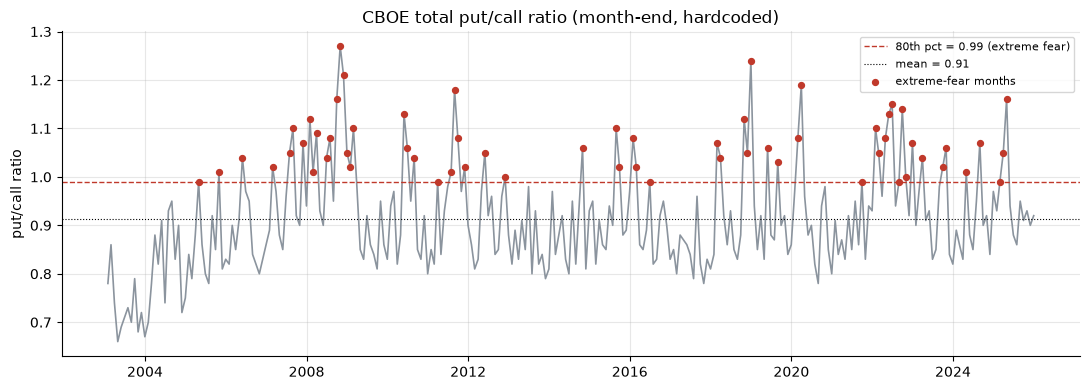

Mean put/call = 0.913, std = 0.107


In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
pcr = data.pcr_series()
ax.plot(pcr.index, pcr.values, color=GREY, lw=1.2)
thr = pcr.quantile(0.80)
ax.axhline(thr, color=RED, ls="--", lw=1.0, label=f"80th pct = {thr:.2f} (extreme fear)")
ax.axhline(pcr.mean(), color="black", ls=":", lw=0.8, label=f"mean = {pcr.mean():.2f}")
fear = pcr[pcr >= thr]
ax.scatter(fear.index, fear.values, color=RED, s=18, zorder=5, label="extreme-fear months")
ax.set_title("CBOE total put/call ratio (month-end, hardcoded)")
ax.set_ylabel("put/call ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../docs/pcr_series.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Mean put/call = {pcr.mean():.3f}, std = {pcr.std():.3f}")


## Buying the fear vs owning the index

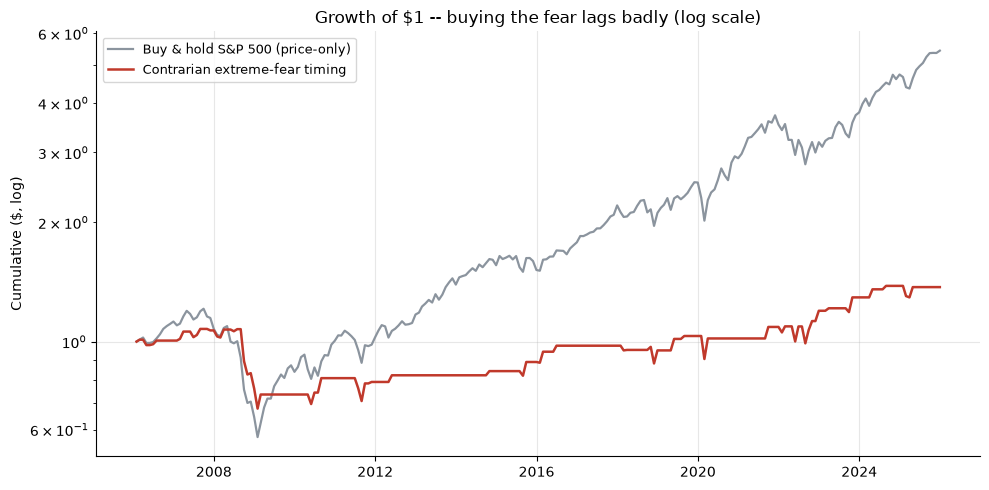

Extreme-fear timing: +2.2%/yr  (invested only 26% of months)
Buy & hold        : +9.6%/yr
-> Sitting in cash 3/4 of the time, you miss most of the bull market.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
if HAVE_REAL:
    cum_strat = (1 + tr["strat"]).cumprod()
    cum_bh    = (1 + tr["bh"]).cumprod()
    ax.plot(cum_bh.index,    cum_bh.values,    color=GREY,  lw=1.6, label="Buy & hold S&P 500 (price-only)")
    ax.plot(cum_strat.index, cum_strat.values, color=RED,   lw=1.8, label="Contrarian extreme-fear timing")
    ax.set_yscale("log")
    ax.set_title("Growth of $1 -- buying the fear lags badly (log scale)")
    ax.set_ylabel("Cumulative ($, log)")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5,
            f"Cache absent\nFrozen: strat = +{R['strat_ann']:.1f}%/yr  vs  buy-hold +{R['bh_ann']:.1f}%/yr",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color=RED)
    ax.set_title("(frozen numbers)")
plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Extreme-fear timing: +{R['strat_ann']:.1f}%/yr  (invested only {R['in_mkt_frac']*100:.0f}% of months)")
print(f"Buy & hold        : +{R['bh_ann']:.1f}%/yr")
print(f"-> Sitting in cash 3/4 of the time, you miss most of the bull market.")


## The killer: extreme-fear months are NOT better than calm months

If the contrarian story were true, the month *after* an extreme put/call spike
would beat an ordinary month. It does not -- if anything it is slightly *worse*.


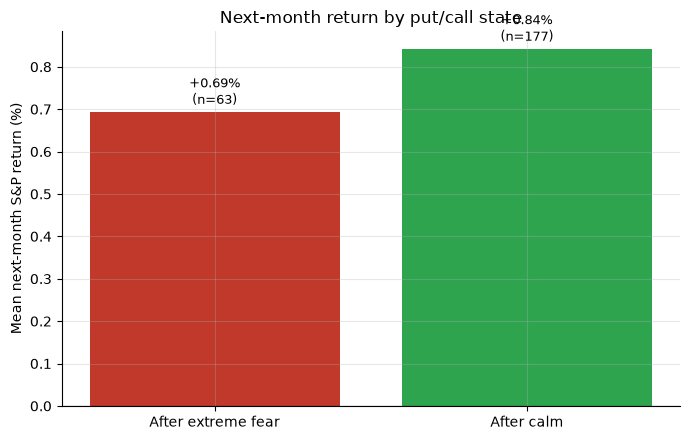

After extreme fear: +0.69%/mo (n=63)
After calm        : +0.84%/mo (n=177)
Difference (fear - calm): -0.15%/mo  Welch t = -0.18  p = 0.86
-> The 'fear bottom' edge is absent (and the wrong sign) on the real tape.


In [5]:
if HAVE_REAL:
    s = sig.iloc[36:]
    fwd = panel["fwd_ret"].iloc[36:]
    fear = fwd[s == 1]; calm = fwd[s == 0]
    fear_mean, calm_mean = fear.mean()*100, calm.mean()*100
    fear_n, calm_n = len(fear), len(calm)
else:
    fear_mean, calm_mean = R["fear_mean"], R["calm_mean"]
    fear_n, calm_n = R["fear_n"], R["calm_n"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["After extreme fear", "After calm"], [fear_mean, calm_mean],
              color=[RED, GREEN])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Mean next-month S&P return (%)")
ax.set_title("Next-month return by put/call state")
for b, v, n in zip(bars, [fear_mean, calm_mean], [fear_n, calm_n]):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:+.2f}%\n(n={n})", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../docs/by_state.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"After extreme fear: {fear_mean:+.2f}%/mo (n={fear_n})")
print(f"After calm        : {calm_mean:+.2f}%/mo (n={calm_n})")
print(f"Difference (fear - calm): {R['fear_minus_calm']:+.2f}%/mo  Welch t = {R['welch_t']:+.2f}  p = {R['welch_p']:.2f}")
print("-> The 'fear bottom' edge is absent (and the wrong sign) on the real tape.")


## The bottom line for the curious

The put/call ratio is a real, well-measured fear gauge -- it spikes exactly where
you'd expect (2008, 2018, 2020). But as a **market-timing buy signal** it fails:

- The month after an extreme-fear spike returns **+0.69%**, *below* the +0.84% of
  a calm month (Welch *t* = -0.18 -- statistically indistinguishable, wrong sign).
- The timing rule earns **+2.2%/yr** versus the index's **+9.6%/yr**, because
  buying only the fear keeps you in cash ~74% of the time and out of the bull run.
- A *random* selection of the same number of in-market months beats the
  fear-timed selection 61% of the time.

There is no contrarian bottom-timing edge here. **Signal: None. Tradability: Mirage.**


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*